In [71]:
import pandas as pd
import ollama 
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, f1_score)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [24]:
import os
import pandas as pd

os.makedirs("data", exist_ok=True)

emails = [
    "Congratulations! You've won a $1,000,000 prize! Click here now",
    "Free Viagra and Cialis - limited time offer!!",
    "Your bank account has been compromised - verify now",
    "You've been selected for an exclusive investment opportunity!!!",
    "Project deadline reminder: Q3 report due Friday",
    "Team meeting rescheduled to 3pm Thursday",
    "Please review the attached budget proposal",
    "Your leave request has been approved",
    "Package delivery attempted - reschedule here",
    "Your subscription is about to expire",
    "Join our webinar on productivity tips",
    "Account security update required"
]

pd.DataFrame({"headline": emails}).to_csv("data/emails.csv", index=False)
print(pd.read_csv("data/emails.csv")) 

                                             headline
0   Congratulations! You've won a $1,000,000 prize...
1       Free Viagra and Cialis - limited time offer!!
2   Your bank account has been compromised - verif...
3   You've been selected for an exclusive investme...
4     Project deadline reminder: Q3 report due Friday
5            Team meeting rescheduled to 3pm Thursday
6          Please review the attached budget proposal
7                Your leave request has been approved
8        Package delivery attempted - reschedule here
9                Your subscription is about to expire
10              Join our webinar on productivity tips
11                   Account security update required


In [25]:
news = [
    "Company XYZ reports record quarterly earnings, beating analyst expectations",
    "Federal Reserve signals potential interest rate cuts amid inflation concerns",
    "MegaCorp announces merger with rival firm in $5 billion deal",
    "New financial regulations set to reshape banking sector by 2025",
    "Tech startup misses revenue targets for third consecutive quarter",
    "Government introduces stimulus package to boost economic growth",
    "Industry giants complete acquisition of smaller competitor",
    "Central bank raises interest rates to combat rising inflation",
    "Pharmaceutical company posts surprise profit increase after drug approval",
    "Trade war tensions escalate, threatening global market stability"
]

pd.DataFrame({"headline": news}).to_csv("data/news.csv", index=False)
print(pd.read_csv("data/news.csv"))

                                            headline
0  Company XYZ reports record quarterly earnings,...
1  Federal Reserve signals potential interest rat...
2  MegaCorp announces merger with rival firm in $...
3  New financial regulations set to reshape banki...
4  Tech startup misses revenue targets for third ...
5  Government introduces stimulus package to boos...
6  Industry giants complete acquisition of smalle...
7  Central bank raises interest rates to combat r...
8  Pharmaceutical company posts surprise profit i...
9  Trade war tensions escalate, threatening globa...


## Task 0: Setting up Ollama (1p)

### a) Set up Ollama and connect to it using either openAI's API or Ollama's own API.
### b) Load the 270m parameter version of the gemma3 model and test it with any prompt.

In [72]:
SMALL_MODEL = "gemma3:270m"

response_small = ollama.chat(
    model=SMALL_MODEL,
    messages=[{"role": "user", "content": "What is python? Answer in one sentence."}]
)

print(f"Small Model ({SMALL_MODEL}) Response")
print(response_small['message']['content'])

Small Model (gemma3:270m) Response
Python is a versatile, high-level programming language known for its readability, extensive libraries, and ease of use.



### c) Load the 1b parameter version of the gemma3 and test it with any prompt.

In [73]:
LARGE_MODEL = "gemma3:1b"

response_large = ollama.chat(
    model=LARGE_MODEL,
    messages=[{"role": "user", "content": "What is python? Answer in one sentence."}]
)

print(f"Large Model ({LARGE_MODEL}) Response")
print(response_large['message']['content'])

Large Model (gemma3:1b) Response
Python is a versatile, high-level, interpreted programming language known for its readability and extensive libraries.


## Task 1: Text classification with Ollama (2p)

In [26]:
# Load the emails dataset
emails_df = pd.read_csv("data/emails.csv")
print("Email dataset:")
display(emails_df.head(12))
print(f"\nTotal emails: {len(emails_df)}")

Email dataset:


,headline
0,"Congratulations! You've won a $1,000,000 prize..."
1,Free Viagra and Cialis - limited time offer!!
2,Your bank account has been compromised - verif...
3,You've been selected for an exclusive investme...
4,Project deadline reminder: Q3 report due Friday
5,Team meeting rescheduled to 3pm Thursday
6,Please review the attached budget proposal
7,Your leave request has been approved
8,Package delivery attempted - reschedule here
9,Your subscription is about to expire



Total emails: 12


### a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. (0.5p)

In [76]:
def classify_email(headline: str, model: str) -> str:
    """
    Classify an email headline as 'spam', 'work', or 'unknown'.
    Returns ONLY the classification label.
    """
    prompt = f"""Classify the following email headline into exactly one of these categories: spam, work, or unknown. Reply with ONLY one word: spam, work, or unknown. No explanation, no punctuation. Email headline: "{headline}" """
    response = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    
    # Extract and clean the response
    result = response['message']['content'].strip().lower()
    
    # Make sure only valid categories returned
    for category in ["spam", "work", "unknown"]:
        if category in result:
            return category
    return "unknown"

# Test to verify function works
test_result = classify_email("Free money - click here now!!!", SMALL_MODEL)
print(f"Test classification: '{test_result}'")

Test classification: 'spam'


### b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

In [77]:
print(f"Classifying emails with {SMALL_MODEL}:")
small_model_results = []
for headline in emails_df['headline']:
    label = classify_email(headline, SMALL_MODEL)
    small_model_results.append(label)
    print(f"  [{label}] {headline}")

emails_df['small_model'] = small_model_results

Classifying emails with gemma3:270m:
  [spam] Congratulations! You've won a $1,000,000 prize! Click here now
  [spam] Free Viagra and Cialis - limited time offer!!
  [spam] Your bank account has been compromised - verify now
  [spam] You've been selected for an exclusive investment opportunity!!!
  [spam] Project deadline reminder: Q3 report due Friday
  [spam] Team meeting rescheduled to 3pm Thursday
  [spam] Please review the attached budget proposal
  [spam] Your leave request has been approved
  [spam] Package delivery attempted - reschedule here
  [spam] Your subscription is about to expire
  [spam] Join our webinar on productivity tips
  [spam] Account security update required


### c) Use larger gemma3 (1b) to classify the emails using the function created in part a). (0.5p)

In [78]:
print(f"Classifying emails with {LARGE_MODEL}:")
large_model_results = []
for headline in emails_df['headline']:
    label = classify_email(headline, LARGE_MODEL)
    large_model_results.append(label)
    print(f"  [{label}] {headline}")

emails_df['large_model'] = large_model_results

Classifying emails with gemma3:1b:
  [spam] Congratulations! You've won a $1,000,000 prize! Click here now
  [spam] Free Viagra and Cialis - limited time offer!!
  [spam] Your bank account has been compromised - verify now
  [spam] You've been selected for an exclusive investment opportunity!!!
  [work] Project deadline reminder: Q3 report due Friday
  [work] Team meeting rescheduled to 3pm Thursday
  [work] Please review the attached budget proposal
  [work] Your leave request has been approved
  [spam] Package delivery attempted - reschedule here
  [spam] Your subscription is about to expire
  [work] Join our webinar on productivity tips
  [spam] Account security update required


### Write a brief comment comparing the results of parts b) and c).
#### The 270m model classified every single email as spam, showing it lacks the language understanding needed to distinguish between email types. The 1b model performed significantly better since it correctly identified the clear work emails as "work" and the obvious spam as "spam". However, the 1b model still struggled with the vague emails, labeling them as spam rather than "unknown". This makes sense as larger models have more parameters, meaning they can better understand context and nuance in language.

### d) Write a script that repeats b) and c) 3 times, storing the results for both models separately.

In [79]:
NUM_RUNS = 3

small_runs = []
large_runs = []

for run in range(1, NUM_RUNS + 1):
    print(f"Run {run}/{NUM_RUNS}")
    
    # Small model run
    small_labels = []
    for headline in emails_df['headline']:
        label = classify_email(headline, SMALL_MODEL)
        small_labels.append(label)
    small_runs.append(small_labels)
    print(f"  Small model done.")
    
    # Large model run
    large_labels = []
    for headline in emails_df['headline']:
        label = classify_email(headline, LARGE_MODEL)
        large_labels.append(label)
    large_runs.append(large_labels)
    print(f"  Large model done.")

print("\nAll runs complete!")

Run 1/3
  Small model done.
  Large model done.
Run 2/3
  Small model done.
  Large model done.
Run 3/3
  Small model done.
  Large model done.

All runs complete!


### For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models.

In [80]:
# Build DataFrames for comparison
small_df = pd.DataFrame({
    'headline': emails_df['headline'],
    'run_1': small_runs[0],
    'run_2': small_runs[1],
    'run_3': small_runs[2],
})

large_df = pd.DataFrame({
    'headline': emails_df['headline'],
    'run_1': large_runs[0],
    'run_2': large_runs[1],
    'run_3': large_runs[2],
})

print(f"Small Model ({SMALL_MODEL}) 3 Runs")
display(small_df)

print(f"Large Model ({LARGE_MODEL}) 3 Runs")
display(large_df)

# Show where results differed across runs
small_df['consistent'] = (small_df['run_1'] == small_df['run_2']) & (small_df['run_2'] == small_df['run_3'])
large_df['consistent'] = (large_df['run_1'] == large_df['run_2']) & (large_df['run_2'] == large_df['run_3'])

print(f"Small model consistency: {small_df['consistent'].sum()}/12 emails got same label all 3 runs")
print(f"Large model consistency: {large_df['consistent'].sum()}/12 emails got same label all 3 runs")

Small Model (gemma3:270m) 3 Runs


,headline,run_1,run_2,run_3
0,"Congratulations! You've won a $1,000,000 prize...",spam,spam,spam
1,Free Viagra and Cialis - limited time offer!!,spam,spam,spam
2,Your bank account has been compromised - verif...,spam,spam,spam
3,You've been selected for an exclusive investme...,spam,spam,spam
4,Project deadline reminder: Q3 report due Friday,spam,spam,spam
5,Team meeting rescheduled to 3pm Thursday,spam,spam,spam
6,Please review the attached budget proposal,spam,spam,spam
7,Your leave request has been approved,spam,spam,spam
8,Package delivery attempted - reschedule here,unknown,spam,spam
9,Your subscription is about to expire,spam,spam,spam


Large Model (gemma3:1b) 3 Runs


,headline,run_1,run_2,run_3
0,"Congratulations! You've won a $1,000,000 prize...",spam,spam,spam
1,Free Viagra and Cialis - limited time offer!!,spam,spam,spam
2,Your bank account has been compromised - verif...,spam,spam,spam
3,You've been selected for an exclusive investme...,spam,spam,spam
4,Project deadline reminder: Q3 report due Friday,work,work,work
5,Team meeting rescheduled to 3pm Thursday,work,work,work
6,Please review the attached budget proposal,work,work,work
7,Your leave request has been approved,work,work,work
8,Package delivery attempted - reschedule here,spam,spam,spam
9,Your subscription is about to expire,spam,spam,spam


Small model consistency: 11/12 emails got same label all 3 runs
Large model consistency: 12/12 emails got same label all 3 runs


### Comment if there were differences and explain why this happened.
#### The 270m model was mostly consistent (11/12) but for the wrong reasons, it defaulted to "spam" for almost everything. The one inconsistency was "Package delivery attempted - reschedule here", which got "unknown" in run 1 but "spam" in runs 2 and 3, showing the small model has some randomness when it is uncertain. The 1b model was perfectly consistent (12/12), producing identical results across all 3 runs. This is because the 1b model is more confident in its classifications due to better language understanding, leaving less room for random variation.

## Task 2: Sentiment analysis with Ollama (2p)

In [81]:
# Load the news dataset
news_df = pd.read_csv("data/news.csv")
print("News dataset:")
display(news_df)
print(f"Total headlines: {len(news_df)}")

News dataset:


,headline
0,"Company XYZ reports record quarterly earnings,..."
1,Federal Reserve signals potential interest rat...
2,MegaCorp announces merger with rival firm in $...
3,New financial regulations set to reshape banki...
4,Tech startup misses revenue targets for third ...
5,Government introduces stimulus package to boos...
6,Industry giants complete acquisition of smalle...
7,Central bank raises interest rates to combat r...
8,Pharmaceutical company posts surprise profit i...
9,"Trade war tensions escalate, threatening globa..."


Total headlines: 10


### a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). (1p)

In [82]:
def analyze_news(headline: str, model: str) -> dict:
    """
    Classify a news headline by topic and sentiment.
    Returns a dict with 'topic' and 'sentiment' keys.
    """
    prompt = f"""Analyze the following financial news headline. Return ONLY a JSON object with exactly these two fields: "topic": one of ["earnings", "mergers", "regulation", "macroeconomics"]; "sentiment": one of ["positive", "negative", "neutral"]. No explanation, no markdown, no backticks, just the raw JSON. Headline: "{headline}" """
    response = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    
    raw = response['message']['content'].strip().replace("```json", "").replace("```", "")
    return json.loads(raw)
   
# Quick test
test = analyze_news("Company reports record profits this quarter", LARGE_MODEL)
print("Test result:", test)

Test result: {'topic': 'earnings', 'sentiment': 'positive'}


### b) Use gemma3 (1b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

In [83]:
print(f"Analyzing news with {LARGE_MODEL}")

topics = []
sentiments = []

for headline in news_df['headline']:
    result = analyze_news(headline, LARGE_MODEL)
    topics.append(result['topic'])
    sentiments.append(result['sentiment'])

news_results_df = pd.DataFrame({
    'headline': news_df['headline'],
    'topic': topics,
    'sentiment': sentiments
})

display(news_results_df)

Analyzing news with gemma3:1b


,headline,topic,sentiment
0,"Company XYZ reports record quarterly earnings,...",earnings,positive
1,Federal Reserve signals potential interest rat...,interest rates,negative
2,MegaCorp announces merger with rival firm in $...,mergers,positive
3,New financial regulations set to reshape banki...,regulation,negative
4,Tech startup misses revenue targets for third ...,earnings,negative
5,Government introduces stimulus package to boos...,macroeconomics,positive
6,Industry giants complete acquisition of smalle...,mergers,positive
7,Central bank raises interest rates to combat r...,macroeconomics,negative
8,Pharmaceutical company posts surprise profit i...,earnings,positive
9,"Trade war tensions escalate, threatening globa...",macroeconomics,negative


### c) Give the same data and prompt to a browser based LLM and ask it to provide the topic and sentiment, giving it the same options. Compare the results of b) and c), which one is more accurate and why? (0.5p)
#### Claude response:
#### | # | headline | topic | sentiment |
#### | 0 | Company XYZ reports record quarterly earnings, beating analyst expectations | earnings | positive |
#### | 1 | Federal Reserve signals potential interest rate cuts amid inflation concerns | macroeconomics | neutral |
#### | 2 | MegaCorp announces merger with rival firm in $5 billion deal | mergers | neutral |
#### | 3 | New financial regulations set to reshape banking sector by 2025 | regulation | neutral |
#### | 4 | Tech startup misses revenue targets for third consecutive quarter | earnings | negative |
#### | 5 | Government introduces stimulus package to boost economic growth | macroeconomics | positive |
#### | 6 | Industry giants complete acquisition of smaller competitor | mergers | neutral |
#### | 7 | Central bank raises interest rates to combat rising inflation | macroeconomics | negative |
#### | 8 | Pharmaceutical company posts surprise profit increase after drug approval | earnings | positive |
#### | 9 | Trade war tensions escalate, threatening global market stability | macroeconomics | negative |

#### Claude performs better because it is trained on broader datasets with stronger reasoning capabilities. In contrast, Gemma3:1b is a much smaller local model optimized for efficiency rather than deep contextual understanding.

## Task 3: Supervised machine learning (5p)

### a) Import the dataset and conduct exploratory data analysis on it. (1p)

Dataset shape: (4119, 21)
First 5 Rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  co

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Target Variable Distribution:
y
no     3668
yes     451
Name: count, dtype: int64


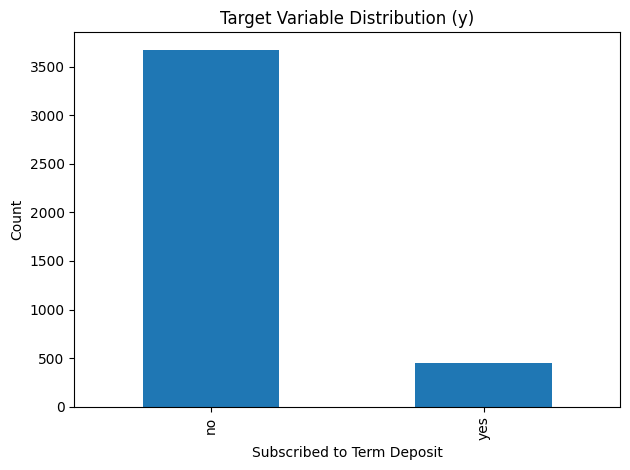

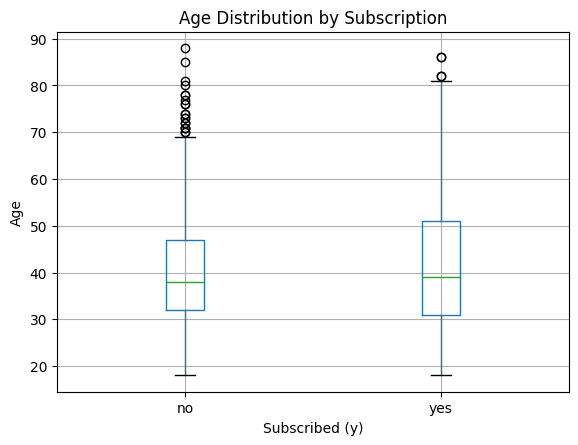

In [84]:
# Import the dataset
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
urllib.request.urlretrieve(url, "bank-additional.zip")

import zipfile
with zipfile.ZipFile("bank-additional.zip", "r") as z:
    z.extractall("data/")

bank_df = pd.read_csv("data/bank-additional/bank-additional.csv", sep=";")

print("Dataset shape:", bank_df.shape)

#Exploratory Data Analysis

# First 5 rows
print("First 5 Rows:")
display(bank_df.head())

# Data types and missing values
print("Data Types and Missing Values:")
print(bank_df.info())

# Summary statistics
print("Summary Statistics:")
display(bank_df.describe())

# Target variable distribution
print("Target Variable Distribution:")
print(bank_df['y'].value_counts())

# Visual: target class balance
bank_df['y'].value_counts().plot(kind='bar', title='Target Variable Distribution (y)')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Visual: age distribution by target
bank_df.boxplot(column='age', by='y')
plt.title('Age Distribution by Subscription')
plt.xlabel('Subscribed (y)')
plt.ylabel('Age')
plt.suptitle('')
plt.show()

### b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

In [85]:
# 1. Fix unknown values
bank_df = bank_df.replace('unknown', np.nan)
print("After replacing 'unknown' with NaN:")
print(bank_df.isna().sum())

# 2. Handle missing values
bank_df = bank_df.dropna()
print("Shape after dropping missing values:", bank_df.shape)

# 3. Encode target: yes -> 1, no -> 0
bank_df['y'] = (bank_df['y'] == 'yes').astype(int)
print("Target distribution after encoding:")
print(bank_df['y'].value_counts())

# 4. Encode categorical columns
cat_cols = bank_df.select_dtypes(include='object').columns.tolist()
bank_df_encoded = pd.get_dummies(bank_df, columns=cat_cols, drop_first=True)

print("Categorical columns to encode:")
display(bank_df_encoded.head())

# 5. Split features and target
X = bank_df_encoded.drop(columns=['y'])
y = bank_df_encoded['y']

# Train / validation / test split (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

# 6. Standardize numeric columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)       
X_test_scaled  = scaler.transform(X_test)

print("First row of scaled training data:")
print(X_train_scaled[0][:5])

After replacing 'unknown' with NaN:
age                 0
job                39
marital            11
education         167
default           803
housing           105
loan              105
contact             0
month               0
day_of_week         0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp.var.rate        0
cons.price.idx      0
cons.conf.idx       0
euribor3m           0
nr.employed         0
y                   0
dtype: int64
Shape after dropping missing values: (3090, 21)
Target distribution after encoding:
y
0    2720
1     370
Name: count, dtype: int64
Categorical columns to encode:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,True,False,False,False,False,False,False,False,True,False
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,True,False,False,False,False,False,False,False,True,False
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,False,False,False,False,False,False,False,True,True,False
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,False,True,False,False,True,False,False,False,True,False
5,32,128,3,999,2,-1.1,94.199,-37.5,0.884,4963.6,...,False,False,False,True,False,True,False,False,False,False


Train: 2163, Validation: 463, Test: 464
First row of scaled training data:
[-0.12491513 -0.49149085 -0.20488169  0.21900786 -0.36568212]


### c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

#### This is a classification task: we predict whether a customer subscribes (yes/no).
#### 1. Logistic Regression: A simple, interpretable baseline for binary classification. Good for understanding which features matter most.
#### 2. Random Forest: An ensemble of decision trees. Handles non-linear relationships and is robust to outliers. Works well with mixed feature types.
#### 3. Gradient Boosting: Builds trees sequentially, each correcting the previous. Often achieves top performance on tabular data.

In [64]:
from sklearn.model_selection import GridSearchCV

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
lr_val_pred = lr.predict(X_val_scaled)
lr_val_acc = accuracy_score(y_val, lr_val_pred)
print(f"Logistic Regression — Validation Accuracy: {lr_val_acc:.4f}")

# Tune: try different regularization strengths
for C in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(C=C, max_iter=1000, random_state=42, class_weight='balanced')
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_val, model.predict(X_val_scaled))
    print(f"  C={C}: val accuracy = {acc:.4f}")

Logistic Regression — Validation Accuracy: 0.8398
  C=0.01: val accuracy = 0.8463
  C=0.1: val accuracy = 0.8414
  C=1: val accuracy = 0.8398
  C=10: val accuracy = 0.8382


In [86]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_val_pred = rf.predict(X_val)
rf_val_acc = accuracy_score(y_val, rf_val_pred)
print(f"Random Forest (default) — Validation Accuracy: {rf_val_acc:.4f}")

# Tune: try different tree depths
for depth in [3, 5, 10, None]:
    model = RandomForestClassifier(n_estimators=100, max_depth=depth,
                                   random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)
    acc = accuracy_score(y_val, model.predict(X_val))
    print(f"  max_depth={depth}: val accuracy = {acc:.4f}")

Random Forest (default) — Validation Accuracy: 0.8942
  max_depth=3: val accuracy = 0.8315
  max_depth=5: val accuracy = 0.8488
  max_depth=10: val accuracy = 0.8855
  max_depth=None: val accuracy = 0.8942


In [66]:
# Model 3: Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_val_pred = gb.predict(X_val)
gb_val_acc = accuracy_score(y_val, gb_val_pred)
print(f"Gradient Boosting (default) — Validation Accuracy: {gb_val_acc:.4f}")

# Tune: try different learning rates
for lr_rate in [0.01, 0.05, 0.1, 0.2]:
    model = GradientBoostingClassifier(n_estimators=100, learning_rate=lr_rate, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_val, model.predict(X_val))
    print(f"  learning_rate={lr_rate}: val accuracy = {acc:.4f}")

Gradient Boosting (default) — Validation Accuracy: 0.9045
  learning_rate=0.01: val accuracy = 0.8948
  learning_rate=0.05: val accuracy = 0.9045
  learning_rate=0.1: val accuracy = 0.9045
  learning_rate=0.2: val accuracy = 0.8997


### d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

In [89]:
# Use the full training data for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Best models from tuning 
best_lr = LogisticRegression(C=0.1, max_iter=1000, random_state=42, class_weight='balanced')
best_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
best_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

print("Cross-Validation (5-fold) F1 Scores")
for name, model, X_data in [
    ("Logistic Regression", best_lr, X_train_scaled),
    ("Random Forest", best_rf, X_train),
    ("Gradient Boosting", best_gb, X_train)
]:
    scores = cross_val_score(model, X_data, y_train, cv=cv, scoring='f1')
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}")

print("Validation Set F1 Scores (train/val/test split)")
best_lr.fit(X_train_scaled, y_train)
best_rf.fit(X_train, y_train)
best_gb.fit(X_train, y_train)

for name, model, X_data in [
    ("Logistic Regression", best_lr, X_val_scaled),
    ("Random Forest", best_rf, X_val),
    ("Gradient Boosting", best_gb, X_val)
]:
    pred = model.predict(X_data)
    print(f"{name}: F1 = {f1_score(y_val, pred):.4f}")

Cross-Validation (5-fold) F1 Scores
Logistic Regression: mean=0.5988, std=0.0177
Random Forest: mean=0.5024, std=0.0715
Gradient Boosting: mean=0.5050, std=0.0199
Validation Set F1 Scores (train/val/test split)
Logistic Regression: F1 = 0.5714
Random Forest: F1 = 0.5391
Gradient Boosting: F1 = 0.5435


#### Cross-validation produced higher F1 scores across all three models compared to the single train/validation/test split. For example, Logistic Regression scored 0.5988 with cross-validation but only 0.5714 on the validation set. Cross-validation performs better here because it trains and tests the model on all parts of the data across 5 different splits, giving a more reliable and stable estimate of performance. The train/val/test split depends on one fixed split, which may be slightly unlucky in how the data was divided. However, cross-validation is more computationally expensive since it trains the model 5 times. For large datasets, the train/val/test split is often preferred for speed. In this case, cross-validation is the better choice for getting a trustworthy performance estimate.

### e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)

Logistic Regression
  Accuracy: 0.8664
  F1 Score: 0.6173
  ROC-AUC:  0.9398
Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.86      0.92       408
         Yes       0.47      0.89      0.62        56

    accuracy                           0.87       464
   macro avg       0.73      0.88      0.77       464
weighted avg       0.92      0.87      0.88       464

Random Forest
  Accuracy: 0.9159
  F1 Score: 0.6422
  ROC-AUC:  0.9289
Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.96      0.95       408
         Yes       0.66      0.62      0.64        56

    accuracy                           0.92       464
   macro avg       0.80      0.79      0.80       464
weighted avg       0.91      0.92      0.91       464

Gradient Boosting
  Accuracy: 0.9116
  F1 Score: 0.5495
  ROC-AUC:  0.9429
Classification Report:
              precision    recall  f1-score   support


,Accuracy,F1,ROC-AUC
Logistic Regression,0.8664,0.6173,0.9398
Random Forest,0.9159,0.6422,0.9289
Gradient Boosting,0.9116,0.5495,0.9429


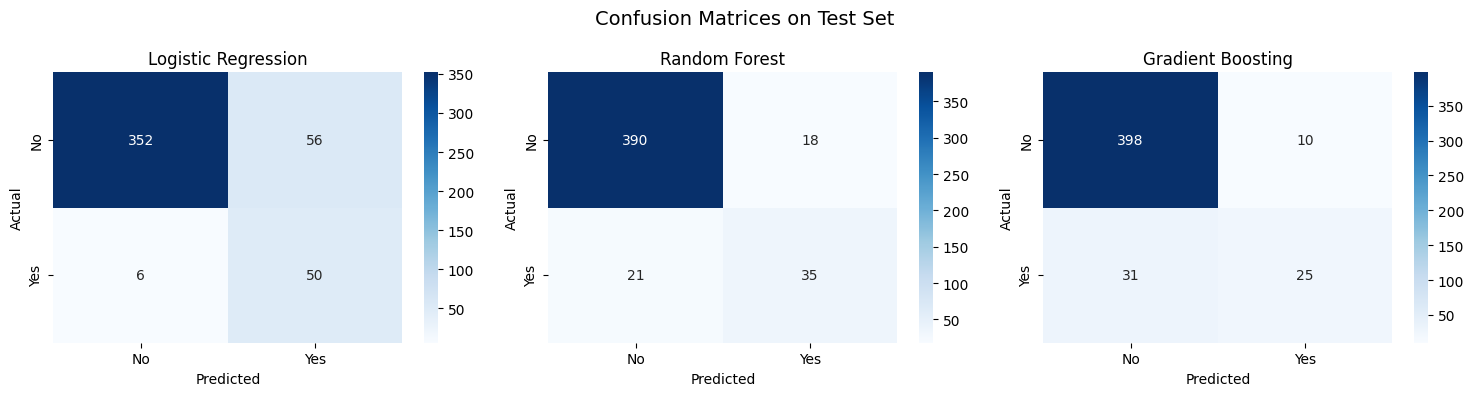

In [92]:
results = {}

for name, model, X_tr, X_te in [
    ("Logistic Regression", best_lr, X_train_scaled, X_test_scaled),
    ("Random Forest",       best_rf, X_train,        X_test),
    ("Gradient Boosting",  best_gb, X_train,         X_test)
]:
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    
    acc  = accuracy_score(y_test, pred)
    f1   = f1_score(y_test, pred)
    roc  = roc_auc_score(y_test, proba)
    
    results[name] = {'Accuracy': acc, 'F1': f1, 'ROC-AUC': roc}
    
    print(f"{name}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC-AUC:  {roc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, pred, target_names=["No", "Yes"]))

# Summary table
print("Summary Table")
display(pd.DataFrame(results).T.round(4))

# Visualize confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model, X_te) in zip(axes, [
    ("Logistic Regression", best_lr, X_test_scaled),
    ("Random Forest",       best_rf, X_test),
    ("Gradient Boosting",  best_gb, X_test)
]):
    pred = model.predict(X_te)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices on Test Set", fontsize=14)
plt.tight_layout()
plt.show()

#### Logistic Regression performed best because of highest recall for "Yes" class (0.89) means it catches the most actual subscribers, highest F1 Score (0.6173) for the "Yes" class, highest ROC-AUC (0.9398) represents best overall ability to distinguish between classes